The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


MC Realizations: 100%|██████████| 100/100 [03:11<00:00,  1.91s/it]


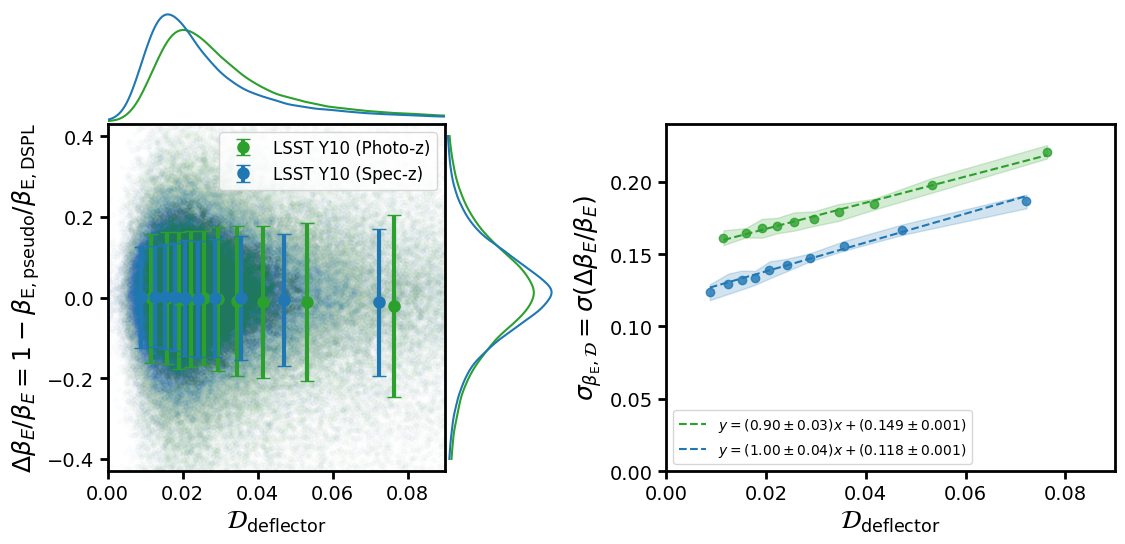

In [10]:
## Photo-z vs Spec-z for LSST Y10
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from tqdm import tqdm
import warnings

# PDSPL Utils Imports
from pdspl_utils.pairing import (
    get_kdtree_pairs, 
    get_pairs_table_PDSPL, 
    inject_observational_errors, 
    compute_dissimilarity,
    plot_beta_E_vs_D_MC
)

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# Global configuration
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

########################################################
# 1. Load and preprocess the GGL data table
########################################################
def preprocess_ggl_table(filepath):
    table = Table.read(filepath, format='fits')
    table['color_D_gr'] = table['mag_D_g'] - table['mag_D_r']
    table['color_D_ri'] = table['mag_D_r'] - table['mag_D_i']
    table.rename_column('size_D', 'R_e_arcsec')
    return table

# Update this path if necessary
GGL_table_LSST_Y10 = preprocess_ggl_table("../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits")

########################################################
# 2. Build configuration dictionary with dynamic errors
########################################################
pdspl_samples = {
    "lsst_y10_photo_z": {"table": GGL_table_LSST_Y10, "name": "LSST Y10 (Photo-z)", "color": "tab:green"},
    "lsst_y10_spec_z":  {"table": GGL_table_LSST_Y10, "name": "LSST Y10 (Spec-z)",  "color": "tab:blue"}
}

base_pairing_keys = ['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri']
base_dissim_keys = ["rel_diff_R_e_arcsec", "rel_diff_z_D", "rel_diff_mag_D_i", "rel_diff_color_D_gr", "rel_diff_color_D_ri"]

# Base errors shared by both setups
base_error_config = {
    'sigma_v_D': 10.0,
    'R_e_arcsec': lambda t: 0.05 * t['R_e_arcsec'],
    'mag_D_i': 1e-3
}

for key, s in pdspl_samples.items():
    s['pairing_keys'] = base_pairing_keys
    s['dissimilarity_keys'] = base_dissim_keys
    s['error_config'] = base_error_config.copy()

# Tailor the redshift errors specifically
pdspl_samples['lsst_y10_photo_z']['error_config']['z_D'] = lambda t: 0.03 * (1 + t['z_D'])
pdspl_samples['lsst_y10_spec_z']['error_config']['z_D'] = 1e-4

########################################################
# 3. Run Error Injection and KD-Tree Pairing
########################################################
N_realizations = 100 # Set lower for a quick test, scale up to 100 for final plots
METRIC = 'rms'
MAX_DISSIMILARITY = 0.1 

# Initialize tracking dictionary
mc_results = {k: {
    'binned_dissim': [], 
    'binned_scatter': [],
    'num_pairs': [],         
    'scatter_in_beta_E': []
} for k in pdspl_samples.keys()}

for i_realization in tqdm(range(N_realizations), desc="MC Realizations"):
    
    for sample_key, s in pdspl_samples.items():
        if len(s["table"]) < 2: continue
            
        # 1. Inject Noise using the new dynamic config
        table_err = inject_observational_errors(s['table'], s['error_config'])
        
        # 2. Find Pairs
        indices, _ = get_kdtree_pairs(table_err, s['pairing_keys'], norm_type='zscore')
        
        # 3. Build PDSPL Tables
        pairs_table = get_pairs_table_PDSPL(s['table'], indices, cosmo_true)
        pairs_table_err = get_pairs_table_PDSPL(table_err, indices, cosmo_true)
        
        # 4. Compute Metric
        pairs_table_err['dissimilarity'] = compute_dissimilarity(
            pairs_table_err, s['dissimilarity_keys'], method=METRIC
        )
        
        # 5. Store State
        s["pairs_analysis"] = {
            "pairs_table": pairs_table,
            "pairs_table_with_errors": pairs_table_err,
            "num_lenses": len(s['table']),
            "num_pairs": len(pairs_table),
            "scatter_in_beta_E": np.std(pairs_table['rel_diff_beta_E']),
            "pair_indices": indices
        }

        mc_results[sample_key]['num_pairs'].append(len(pairs_table))
        mc_results[sample_key]['scatter_in_beta_E'].append(np.std(pairs_table['rel_diff_beta_E']))
        
        # 6. Binning for MC aggregation
        mask = (pairs_table_err['dissimilarity'] < MAX_DISSIMILARITY) & (np.isfinite(pairs_table['rel_diff_beta_E']))
        dissim_masked = pairs_table_err['dissimilarity'][mask]
        delta_beta_masked = pairs_table['rel_diff_beta_E'][mask]
        
        percentiles = np.percentile(dissim_masked, np.arange(0, 101, 10))
        digitized = np.digitize(dissim_masked, percentiles)
        
        run_dissim, run_scatter = [], []
        for i in range(1, len(percentiles)):
            bin_mask = (digitized == i)
            run_dissim.append(np.median(dissim_masked[bin_mask]) if np.any(bin_mask) else np.nan)
            run_scatter.append(np.nanstd(delta_beta_masked[bin_mask]) if np.any(bin_mask) else np.nan)
            
        mc_results[sample_key]['binned_dissim'].append(run_dissim)
        mc_results[sample_key]['binned_scatter'].append(run_scatter)

########################################################
# 4. Plot Scatter vs Dissimilarity Comparison
########################################################
# Adjusting the alpha of the scatter plot temporarily inside the plotting function mapping
# if you want clearer visibility, though the default function handles it well.

fig_linear = plot_beta_E_vs_D_MC(
    pdspl_samples, 
    mc_results, 
    fit_type='linear',
    show_fit_eqn_label=True
)

plt.show()

# Inference

In [2]:
# --- 1. SETUP & TRUTH ---
from astropy.cosmology import Flatw0waCDM
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
from pdspl_utils.plotting import plot_dspl_corner

truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}
fixed_params = {'h0': 70.0}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

In [3]:
# --- 2. DEFINE THE SCENARIO USING LSST Y10 SPEC-Z ---
specz_data = pdspl_samples['lsst_y10_spec_z']['pairs_analysis']

# Scale down to 2000 lenses for a faster test run, just like the example
down_sampling_factor = len(specz_data['pairs_table']) / 2000  

scenario = {
    'name': 'LSST Y10 (Spec-z Deflectors)',
    'down_sampling': down_sampling_factor, 
    'num_lenses': len(specz_data['pairs_table']), 
    'coeffs': specz_data['scatter_vs_dissimilarity_fit_coeffs'], # Using native Y10 spec-z coefficients
    'pairs_table': specz_data['pairs_table'],                    # Using native Y10 spec-z population
    'pairs_table_with_errors': specz_data['pairs_table_with_errors'],
    'redshift_error_rel': [0.0001, 0.03, 0.03],                  # Spec-z for deflectors, photo-z for sources
    'backend_path': None,
}



In [6]:
# --- 3. GENERATE MOCK DATASET ---
num_samples = int(scenario['num_lenses'] / scenario['down_sampling'])
kwargs_list = []

print(f"Generating mock dataset for {num_samples} lenses...")
random_indices = np.random.choice(len(scenario['pairs_table']), size=num_samples, replace=False)

for i in random_indices:
    z_lens = scenario['pairs_table']["z_D"][i]
    z1 = scenario['pairs_table']["z_S1"][i]
    z2 = scenario['pairs_table']["z_S2"][i]
    
    dissimilarity = scenario['pairs_table_with_errors']['dissimilarity'][i]
    sigma_beta_intrinsic = np.polyval(scenario['coeffs'], dissimilarity)
    
    sigma_beta_meas, sigma_beta_los = 0.01, 0.01
    sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
    
    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=z_lens, z1=z1, z2=z2,
        lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
        gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
        sigma_beta_intrinsic=sigma_beta_intrinsic,
        sigma_meas_rel=sigma_meas_rel,
        dissimilarity=dissimilarity,
        down_sampling=scenario['down_sampling'], 
        with_noise=False, # For ASIMOV inference
        cosmo=cosmo_true, 
        redshift_error_rel=scenario['redshift_error_rel']
    ))



Generating mock dataset for 1999 lenses...


In [7]:
# --- 4. RUN INFERENCE ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1, 'lambda_sigma': 0.01,
    'gamma_pl': 0.1, 'gamma_sigma': 0.01
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5)
}

# Isolate scatter coefficients to freeze them in the MCMC
coeffs = scenario.get('coeffs', [0.0])
c0, c1, c2 = 0.0, 0.0, 0.0
if len(coeffs) == 1: c0 = coeffs[0]
elif len(coeffs) == 2: c1, c0 = coeffs
elif len(coeffs) >= 3: c2, c1, c0 = coeffs[-3:]

fixed_params_sc = fixed_params.copy()
fixed_params_sc['beta_c0'] = c0
fixed_params_sc['beta_c1'] = c1
fixed_params_sc['beta_c2'] = c2

print(f"\nRunning MCMC Inference...")
samples, labels = run_dspl_inference(
    kwargs_list,
    n_walkers=64,
    n_steps=2000, 
    n_burn=500,
    initial_guess=my_guess,
    fixed_params=fixed_params_sc,
    initial_scatter=my_spreads,
    priors=my_priors,
    backend_path=scenario['backend_path']
)

print("\n--- Inference Complete ---")
print("Median results:")
for i, label in enumerate(labels):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    print(f"{label}: {q50:.3f} (+{q84-q50:.3f} / -{q50-q16:.3f})")


Running MCMC Inference...
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [10:05<00:00,  3.30it/s]


--- Inference Complete ---
Median results:
$\Omega_m$: 0.363 (+0.130 / -0.156)
$w_0$: -0.973 (+0.376 / -0.238)
$w_a$: 0.037 (+1.382 / -2.328)
$\bar{\lambda}_{\rm int}$: 0.994 (+0.016 / -0.015)
$\sigma({\lambda}_{\rm int})$: 0.043 (+0.022 / -0.026)
$\bar{\gamma}_{\rm pl}$: 2.013 (+0.027 / -0.026)
$\sigma({\gamma}_{\rm pl})$: 0.166 (+0.011 / -0.017)



Generating corner plot...


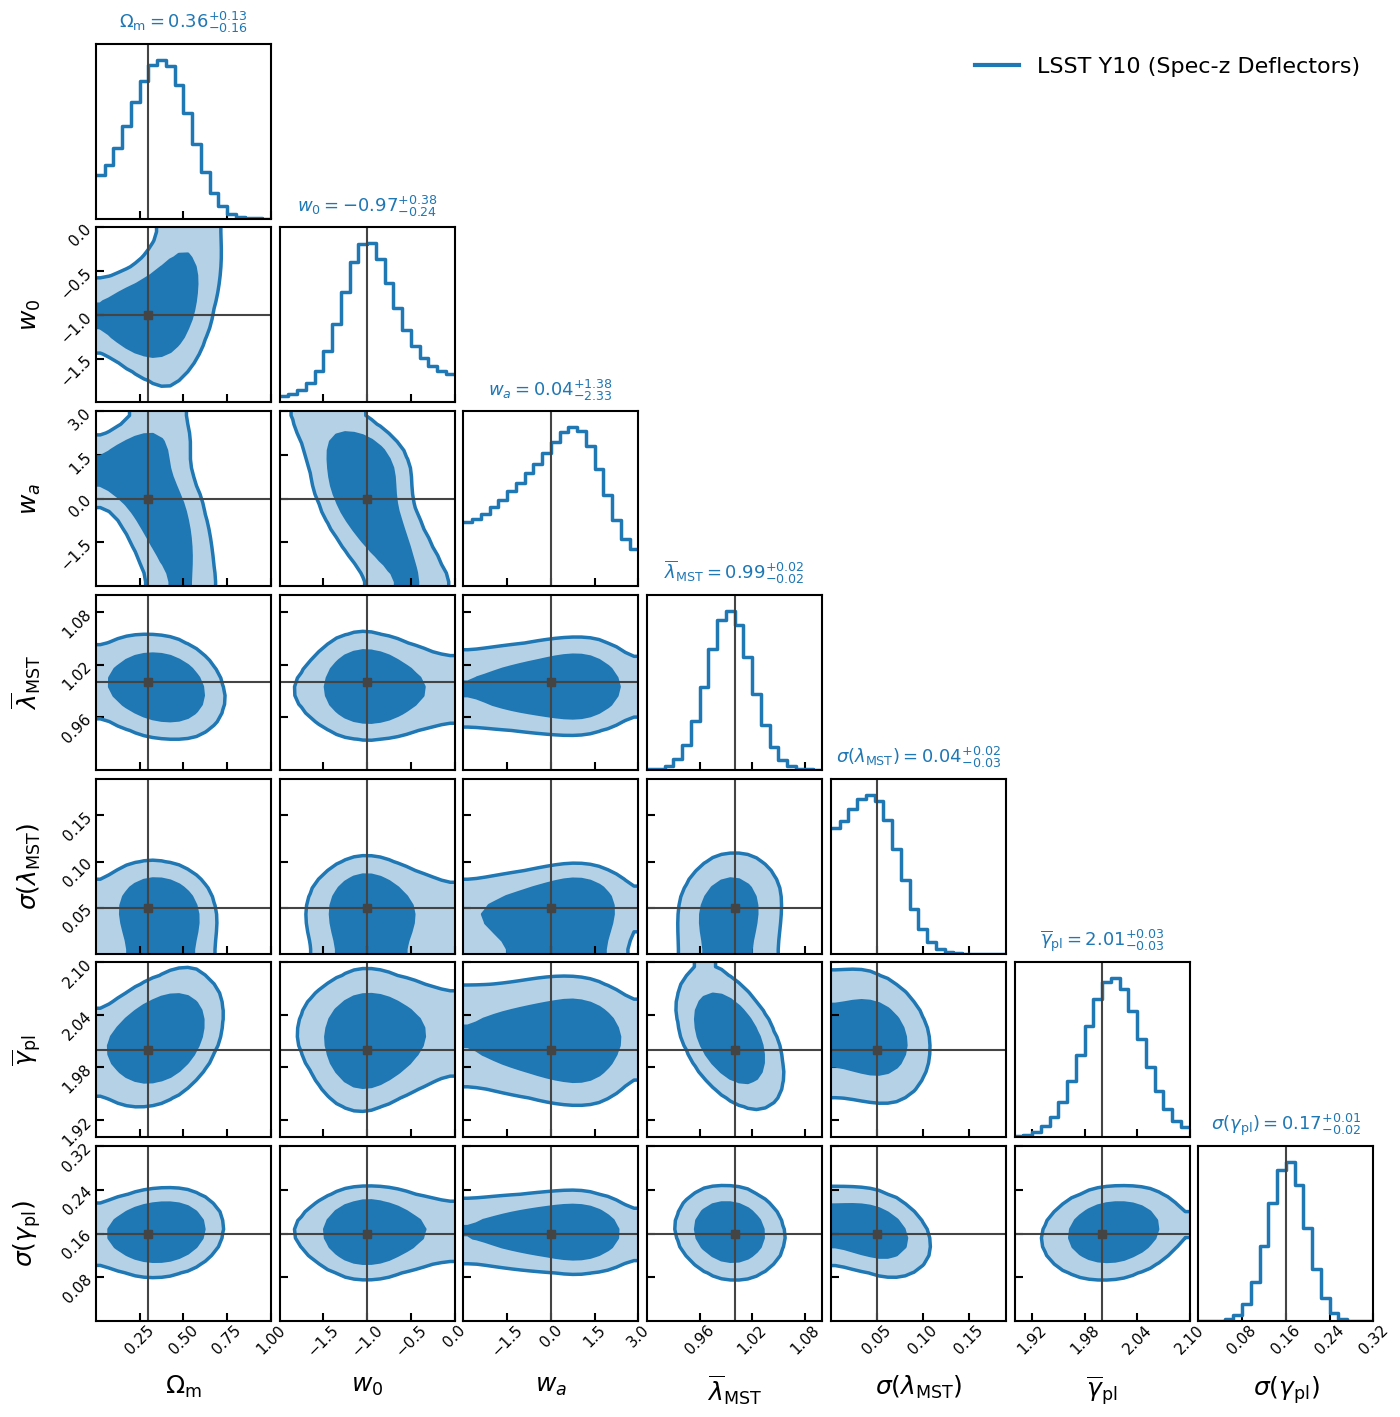

In [9]:
# --- 5. PLOT CORNER PLOT ---
# Prepare the scenario dictionary for the plotting function
scenarios_to_plot = {
    'lsst_y10_specz': {
        'name': 'LSST Y10 (Spec-z Deflectors)',
        'samples': samples,  
        'color': '#1f77b4'   # Blue
    }
}

latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm MST}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
    'lambda_sigma': r"$\sigma({\lambda}_{\rm MST})$"
}

custom_ranges = [
    (0, 1),             # om
    (-2, 0),            # w0
    (-3, 3),            # wa
    (truth['lambda_int'] - 0.1, truth['lambda_int'] + 0.1), # lambda_int
    (0.0, 0.19),        # lambda_sigma
    (truth['gamma_pl'] - 0.1, truth['gamma_pl'] + 0.1),     # gamma_pl
    (0.0, 0.32),        # gamma_sigma
]

print("\nGenerating corner plot...")
fig = plot_dspl_corner(
    scenarios=scenarios_to_plot, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=['lsst_y10_specz'], 
    custom_ranges=custom_ranges, 
    latex_labels=latex_labels, 
    figsize=(14, 14),
    show_multiple_titles=True
)

plt.show()